In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd

import h3

from ev_sim.shapely import *
from ev_sim.distance import distance
from ev_sim.constants import REGION_POLYGONS

In [2]:
AM_PEAK = 592  # 7am - 10am
MIDDAY = 593  # 10am - 3pm
PM_PEAK = 594  # 3pm - 7pm
OFF_PEAK = 595  # 7pm - 7am

WEEKDAY = 1
SATURDAY = 2
SUNDAY = 3

In [3]:
def load_gdf(path: str, geoID: str):
    gdf = gpd.read_file(path)

    # gdf is a dataframe of geographical zones represented as MultiPolygons
    # extract the centroids and lat/lon bounds of each zone
    gdf["lat"] = np.radians(gdf["geometry"].apply(lambda x: x.centroid.coords[0][1]))
    gdf["lon"] = np.radians(gdf["geometry"].apply(lambda x: x.centroid.coords[0][0]))
    gdf[["lon_min", "lat_min", "lon_max", "lat_max"]] = gdf["geometry"].apply(
        lambda poly: np.radians(pd.Series(poly.bounds))
    )

    gdf["geoId"] = gdf[geoID].astype("Int64")
    return gdf


def sample_semcog_data(df: pd.DataFrame, gdf: pd.DataFrame) -> pd.DataFrame:
    # merge geojson dataframe to semcog data
    n_external = ((df["origin_tract"] == -1) + (df["destination_tract"] == -1)).sum()

    n = len(df)
    df = df.merge(gdf[["geoId", "lon_min", "lat_min", "lon_max", "lat_max"]],
                  left_on="origin_tract", right_on="geoId", how="inner")
    df = df.merge(gdf[["geoId", "lon_min", "lat_min", "lon_max", "lat_max"]],
                  left_on="destination_tract", right_on="geoId", how="inner", suffixes=("_pick", "_drop"))
    print(f"Dropped {n - len(df)} of {len(df)} rows when merging zone data to trips")

    # sample times
    df["start_time"] = df["time_of_day"].map({AM_PEAK: 7, MIDDAY: 10, PM_PEAK: 15, OFF_PEAK: 19})
    df["end_time"] = df["time_of_day"].map({AM_PEAK: 10, MIDDAY: 15, PM_PEAK: 19, OFF_PEAK: 31})  # 31:00 mod 24 = 7 AM
    df["start_time"] *= 3600  # convert to seconds
    df["end_time"] *= 3600  # convert to seconds

    # split df into weekend and weekday, then repeat weekday df once for each weekday (0, ..., 4)
    weekday_df = df[df["wday_type"] == WEEKDAY]
    weekend_df = df[df["wday_type"] != WEEKDAY]
    weekday_df = weekday_df.loc[weekday_df.index.repeat(5)].copy()  # repeat df once for each weekday
    # set wday_type to (0, 1, 2, 3, 4) repeated
    weekday_df["wday_type"] = np.tile(np.arange(0, 5), sum(df["wday_type"] == WEEKDAY))

    weekend_df.loc[:, "wday_type"] = weekend_df["wday_type"].map({SATURDAY: 5, SUNDAY: 6})
    df = pd.concat([weekday_df, weekend_df], ignore_index=True)  # combine weekend & weekday dfs

    # sample number of daily trips from a Poisson distribution with mean daily_trips
    rng = np.random.default_rng()
    df["trips"] = rng.poisson(df["daily_trips"])
    df = df.reindex(df.index.repeat(df["trips"]))

    # sample trip start times
    df["created_at"] = np.random.uniform(df["start_time"], df["end_time"])
    df["created_at"] %= 24 * 3600  # modulo 24 hours
    df["created_at"] += 24 * 3600 * df["wday_type"]
    df["created_at"] = df["created_at"].astype("uint32")

    df["pick_lat"] = np.random.uniform(low=df["lat_min_pick"], high=df["lat_max_pick"]).astype("float32")
    df["pick_lon"] = np.random.uniform(low=df["lon_min_pick"], high=df["lon_max_pick"]).astype("float32")
    df["drop_lat"] = np.random.uniform(low=df["lat_min_drop"], high=df["lat_max_drop"]).astype("float32")
    df["drop_lon"] = np.random.uniform(low=df["lon_min_drop"], high=df["lon_max_drop"]).astype("float32")

    df["pax"] = np.random.choice(np.arange(1, 6, dtype="uint8"), size=len(df), p=[0.775, 0.15, 0.04, 0.02, 0.015])

    df.drop(["origin_bg", "destination_bg", "geoId_pick", "geoId_drop",
             "origin_tract", "destination_tract",
             "distance_mi", "daily_pmt", "daily_trips", "trips",
             "wday_type", "start_time", "end_time", "time_of_day",
             "lon_min_pick", "lat_min_pick", "lon_max_pick", "lat_max_pick",
             "lon_min_drop", "lat_min_drop", "lon_max_drop", "lat_max_drop"], axis=1, inplace=True, errors="ignore")

    return df


def vectorized_latlng_to_cell(lat, lon, res: int, is_radians: bool = True):
    if is_radians:
        lat = np.rad2deg(lat)
        lon = np.rad2deg(lon)

    cells = np.vectorize(h3.latlng_to_cell)(lat, lon, res)
    return np.vectorize(h3.str_to_int)(cells)


def preprocess_requests(df: pd.DataFrame):
    df["predicted_lm_dist"] = distance(df["pick_lat"], df["pick_lon"], df["drop_lat"], df["drop_lon"])

    df.sort_values("created_at", inplace=True, ignore_index=True)
    df.reset_index(drop=True, inplace=True)


def preprocess_riders(df):
    df.sort_values("created_at", inplace=True, ignore_index=True)
    df.reset_index(drop=True, inplace=True)

...sampling trips
Dropped 107883 of 8137112 rows when merging zone data to trips


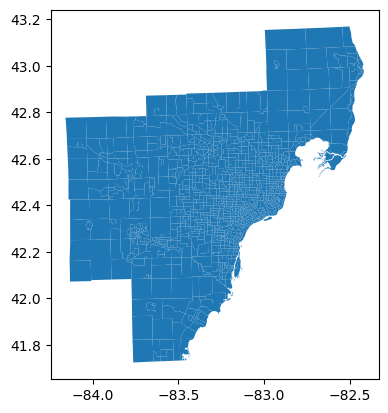

In [4]:
gdf = load_gdf("data/semcog/2020_Census_Tracts.geojson", geoID="geoid20")
gdf.plot()

df = pd.read_csv("data/semcog/SEMCOG_Person_Travel_2019_vs_2024_v14-793.csv")
print("...sampling trips")
raw_trips = sample_semcog_data(df, gdf)

In [5]:
REGION = "washtenaw"

if REGION == "se-michigan":
    trips = raw_trips.copy()
else:
    polygon = REGION_POLYGONS[REGION]
    print("...cropping trips")
    road_intersections = get_road_boundary_intersections(polygon)
    print(f"found {len(road_intersections)} road intersections")
    trips = snap_trips_to_boundary_points(raw_trips, polygon, road_intersections)

trips.head()

...cropping trips
found 21 road intersections


,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax
0,29585,0.740085,-1.461912,0.740521,-1.462027,1
1,30062,0.740192,-1.462229,0.740546,-1.460351,3
2,29423,0.739736,-1.461869,0.740521,-1.462027,1
3,28247,0.740156,-1.462178,0.740521,-1.462027,1
4,31666,0.740393,-1.462189,0.740521,-1.462027,2


In [6]:
# run this to save the trips to a parquet file

preprocess_requests(trips)
print(f"Saving {REGION}: {len(trips)} weekly trips")

trips.to_parquet(f"data/requests/{REGION}.parquet")
print(trips.dtypes)
trips.head()

Saving washtenaw: 8311881 weekly trips
created_at            uint32
pick_lat             float32
pick_lon             float32
drop_lat             float32
drop_lon             float32
pax                    uint8
predicted_lm_dist    float32
dtype: object


,created_at,pick_lat,pick_lon,drop_lat,drop_lon,pax,predicted_lm_dist
0,0,0.737676,-1.461613,0.737774,-1.461712,1,1.569275
1,0,0.737380,-1.458139,0.736874,-1.459682,1,10.704159
2,0,0.739133,-1.458201,0.738153,-1.461883,1,24.035282
3,0,0.738141,-1.460971,0.738129,-1.460742,1,1.948413
4,0,0.738966,-1.463621,0.737871,-1.461377,1,16.696194


In [8]:
REGION = "washtenaw"

polygon = REGION_POLYGONS[REGION]
print("...cropping trips")
road_intersections = get_road_boundary_intersections(polygon)
print(f"found {len(road_intersections)} road intersections")

for mode in ("internal", "external", "inbound", "outbound"):
    trips = snap_trips_to_boundary_points(raw_trips, polygon, road_intersections, mode=mode)

    print(f"{mode} trips:", len(trips))
    trips.to_parquet(f"output/semcog/{mode}-{REGION}-trips.parquet")

...cropping trips
found 21 road intersections
internal trips: 5997767
external trips: 2308166
inbound trips: 1167472
outbound trips: 1140694


In [17]:
REGION = "detroit"

polygon = REGION_POLYGONS[REGION]
fleets = {"ann-arbor": (7500, 10000, 12500, 15000),
          "washtenaw": (30000, 35000, 40000, 45000, 50000),
          "detroit": (30000, 35000, 40000, 45000, 50000)}[REGION]

for n_riders in fleets:
    riders = sample_points_in_polygon(polygon, n_riders, radians=True)
    riders["created_at"] = np.uint32(0)
    riders["lifetime"] = np.uint32(24 * 7 * 3600)
    preprocess_riders(riders)

    riders.to_parquet(f"data/riders/{REGION}-{n_riders}.parquet")

print(riders.dtypes)
riders.head()

lat           float32
lon           float32
created_at     uint32
lifetime       uint32
dtype: object


,lat,lon,created_at,lifetime
0,0.739168,-1.452008,0,604800
1,0.738892,-1.450835,0,604800
2,0.739224,-1.450118,0,604800
3,0.739521,-1.448994,0,604800
4,0.739505,-1.447914,0,604800
